In [19]:

"""Importamos las librerías"""
import math, random, json, pathlib, os
from typing import List, Tuple
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader,  WeightedRandomSampler, Subset, random_split
from collections import Counter
import numpy as np
from sklearn.model_selection import train_test_split



# FUNCIONES COMUNES 


## Función para conseguir Reproducibilidad al fijar semillas


In [20]:


def set_seed(seed_value=42):
    """
    Fija la semilla para la reproducibilidad en Python, NumPy y PyTorch.
    """
    # 1. Semilla de Python (Hash, etc.)
    random.seed(seed_value)
    os.environ['PYTHONHASHSEED'] = str(seed_value)
    
    # 2. Semilla de NumPy (para preprocesamiento y funciones auxiliares)
    np.random.seed(seed_value)
    
    # 3. Semilla de PyTorch (CPU)
    torch.manual_seed(seed_value)
    
    # 4. Semilla de PyTorch (GPU / CUDA)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed_value)
        torch.cuda.manual_seed_all(seed_value) # Para múltiples GPUs
        
        # 5. Configuración para operaciones determinísticas en la GPU
        # Esto puede ralentizar un poco el entrenamiento, pero garantiza la reproducibilidad.
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False

## Obtención de los datos desde archivo Fasta
 Para la tarea de clasificación es necesario devolver un listado de secuencias y un listado de las clases a la ue pertenecen cada secuencia.

In [21]:
"""El uso de esta función auxiliar es para manejar si la secuencia debe añadirse o no al cojunto de datos con el que vamos a trabajar
para que sea facilmente manejable el extraer solo los datos de las 5 clases mayoritarias o los de todas las clases"""

def check_addition(biotype, just_selection):
    selected_biotypes = [ 'lncRNA','snRNA', 'miRNA', 'misc_RNA', 'snoRNA']
    if just_selection:
        if biotype in selected_biotypes:
            return True
        return False
    return True

#Esta función filtra directamente los datos para que solo devuelva aquellas secuencias que son de las clases permitidas
def read_fasta(path, just_selection = False) -> List[str]:
    """Comenzamos inicializando una lista vacía cur en la que se irán acumulando los tramos de las secuencias (las líneas que no son la cabecera)
        Además inicializamos un diccionario data_dict para poder guardar las secuencias como valores asociados a sus identificadores como claves
        El valor del id y del biotipo de cada secuencia lo inicializamos a None inicialmente."""
    cur = []; seqs = []; targets = []; biotype = None; 
    with open(path) as f:
        """Abrimos el archivo con los datos e iteramos por todas sus líneas. Debemos tener en cuenta que hay dos tipos de líneas en el archivo.
        Tenemos las cabeceras, que contienen los metadatos de las secuencias y los tramos de secuencias. Una misma secuencia estará dividida en varios tramos.
        La forma que tenemos de distinguir entre los tipos de líneas del dataset es ver si comienzan por el caracter '>' """
        for line in f:
            if line.startswith(">"):   #EL iterador ha llegado a una nueva secuencia.
                """Si la línea actual comienza por el caracter >, significa que estamos ante una cabecera y que comienza una nueva secuencia."""
                """Si la secuencia es la primera del archivo, no entrará en el siguiente if y pasará directamente a extraer el id y biotipo de esa primera secuencia
                quedando así las variables del mismo nombre con valores distintos a None, que es como se inicializan"""
                """Si es una secuencia que no es la primera del archivo, el id y el biotipo tendrán el valor propio de la secuencia anterior que hemos acabado de iterar pero que todavía no hemos guardado
                 además cur guardará todos los tramos de la secuencia anterior que hemos acabado de iterar """
                if biotype and cur: 
                    if check_addition(biotype, just_selection): #if biotype in selected_biotypes
                        full_sequence = "".join(cur)   #Unimos todos los tramos de una misma secuencia
                        """Añadimos la secuencia a la lista de secuencias y el tipo de secuencia a su lista correspondiente"""
                        seqs.append(full_sequence)
                        targets.append(biotype)
                    cur = [] # Reiniciar para la nueva secuencia
                """Tanto si es la primera línea del proyecto como si es otra cualquiera, se extrae de la cabecera el biotipo"""
                headers = line.split() 
                biotype = headers[4].split(":")[1] 
            else:  
                """Si la línea actual no comienza por el signo >, significa que estamos ante un trozo de la cadena actual, por lo que añadimos dicho trozo
                a la lista cur para ir acumulando todos los tramos de la secuencia actual"""                             
                cur.append(line.strip())        

        if cur: 
            full_sequence = "".join(cur)
            seqs.append(full_sequence)
            targets.append(biotype)
    return seqs, targets


if __name__ == "__main__":
    fasta = "data/rna_small.fasta" #
    seqs, biotypes = read_fasta(fasta, just_selection=False)
    print('Número de biotipos distintos: ',len(seqs))
    print(len(biotypes))

    print(seqs[:10])
    print(biotypes[:10])


   

Número de biotipos distintos:  41635
41635
['GCUCUCUUGCCUGCCGCCACAUAAGACAUGACUUUGCUCCUCAUUCAGCUUCCGCCAUGAUUCUGAGGCCUCCCCAGCGACGUGAAACUCUUCAAUAAAUAUAGACUGCCGUAUCUCUAUGCAUCAGACAUGUCCAUCCUUUGGUUGAGCGAGACACAGGGUGAUACGCACUCGCAGGUGCAUACAUGUCCUAUCCUGGUCUGUGAUUUUUCUGUCCAAGAUGGUGGCUGUUGUACCCUUGAUUUUCUGAAGUCACCAGCACACAGCCUCAGUGCCAGUGGUCAUCAGCCGUGUUAUCAGCUUUCAGAAUUGGAGAGAUGGGGACCCAGUUUCAUUCUUCCACGUGUUUGCUGUCACUUCUGAUAUGCAUACAGCAAUUUGAAUUGACACUGUACAUUAACCAGUAAGAUGAGCUCUGAUUUUGCUCUGACAGCCUGGGGAUGAGGAGCAAGUUGACAAAAUGCUGCAACUUCUGAGGAGGAAAAAUAAAUCUUACCUAGGAAA', 'GUAUUAUCUACAGGCACUAAGAUCCUGAAAAUGUCUUUUCCUCUUCACAUUACACACAAGGAAACCAGACUGUGAACAUAACAAUGAGUUACUUGAAAAUUAAAGGACCCUGAUCCAUCAAUAUGACUACACAUUUGAUUGGACAAAGUUAAAGCAGAAAGCAGCACAGCAGGCAGCCUCUUCUAGUGGGAGGGGCAGCAGGCCCAAACCCCAACAGGGUAUUUAGAGAAAUUCAAUCAGAGACGAUGGAACUAAAGCUGGCCCUUCUGUGCAUACCUGUUUCCUAAAGAAAUGUUUACUCCUGGAUUGGGUCAGCCCCUCUGCAUUUACCUAUAAGAAUCUACAUACAAGCUUGUCUAUCCAUCCUGCAUAGAGCACAAGUCACAGAAGAAAAGCUCCUCUCCAUAAAUUGCUUAACAUAGUAAUCAAUAUCUCUUCACAUUUUCA

## Generación del vocabulario

In [22]:
"""Obtenemos el vocabulario, como todas las convinaciones posibles de 3 nucleótidos. Además añadimos al vocabulario
4 tokens especiales, de Padding, enmascaramiento, token desconocido, y CLS usado para agrupar el conexto de las secuencias en un único vector
con tal de poder llevar a cabo tareas downstream tras el preentrenamiento"""


K = 3
BASES = ["A","C","G","U"]
def all_kmers(k=3):
    vocab = []
    def rec(prefix, k):
        if k==0:
            vocab.append(prefix)
            return
        for b in BASES:
            rec(prefix+b, k-1)
    rec("", k)
    return vocab

kmers = all_kmers(K)  # 64 tokens
print("kmers: ",kmers)
SPECIAL = ["[PAD]","[CLS]","[MASK]","[UNK]"]
#itos es el vocabulario con el que vamos a trabajar de 64 tokens de nucleótidos + 4 tokens especiales
itos = SPECIAL + kmers
#stoi se trata de un diccionario que tiene como clave el token del vocabulario (3-kmer o token especial), y como valor el índice.
#simplemente permite mapear los tokens a su índice en el vocabulario.
stoi = {t:i for i,t in enumerate(itos)}
PAD, CLS, MASK, UNK = [stoi[s] for s in SPECIAL]
print("Vocabulatio: ",stoi)
print("Tamaño vocabulario:", len(itos))

kmers:  ['AAA', 'AAC', 'AAG', 'AAU', 'ACA', 'ACC', 'ACG', 'ACU', 'AGA', 'AGC', 'AGG', 'AGU', 'AUA', 'AUC', 'AUG', 'AUU', 'CAA', 'CAC', 'CAG', 'CAU', 'CCA', 'CCC', 'CCG', 'CCU', 'CGA', 'CGC', 'CGG', 'CGU', 'CUA', 'CUC', 'CUG', 'CUU', 'GAA', 'GAC', 'GAG', 'GAU', 'GCA', 'GCC', 'GCG', 'GCU', 'GGA', 'GGC', 'GGG', 'GGU', 'GUA', 'GUC', 'GUG', 'GUU', 'UAA', 'UAC', 'UAG', 'UAU', 'UCA', 'UCC', 'UCG', 'UCU', 'UGA', 'UGC', 'UGG', 'UGU', 'UUA', 'UUC', 'UUG', 'UUU']
Vocabulatio:  {'[PAD]': 0, '[CLS]': 1, '[MASK]': 2, '[UNK]': 3, 'AAA': 4, 'AAC': 5, 'AAG': 6, 'AAU': 7, 'ACA': 8, 'ACC': 9, 'ACG': 10, 'ACU': 11, 'AGA': 12, 'AGC': 13, 'AGG': 14, 'AGU': 15, 'AUA': 16, 'AUC': 17, 'AUG': 18, 'AUU': 19, 'CAA': 20, 'CAC': 21, 'CAG': 22, 'CAU': 23, 'CCA': 24, 'CCC': 25, 'CCG': 26, 'CCU': 27, 'CGA': 28, 'CGC': 29, 'CGG': 30, 'CGU': 31, 'CUA': 32, 'CUC': 33, 'CUG': 34, 'CUU': 35, 'GAA': 36, 'GAC': 37, 'GAG': 38, 'GAU': 39, 'GCA': 40, 'GCC': 41, 'GCG': 42, 'GCU': 43, 'GGA': 44, 'GGC': 45, 'GGG': 46, 'GGU': 47, '

## Función Tokenizadora de las secuencias
 Función que tokeniza las secuencias de ARN pasando de cadenas de caracteres a tokens del vocabulario. 
 Lo hace siguiendo un enfoque de recorrido solapado, es decir, si la cadena es AUCG, tenemos dos tokens AUC y UCG
 Pasándole una secuencia de nucleótidos devuelve una secuencia de los tokens que componen la secuencia inicial.
 

In [23]:
"""Esta función sería nuestro tokenizador, recibe como parámetro la secuencia completa
Primero: Reemplaza aquellas bases nitrogenadas T por U 
Segundo: Por cada codón de la secuencia (Kmer de longitud 3),  comprueba que los nucleótidos que componen el Kmer sean nucleótidos conocidos,
es decir nucleótidos del conjunto (A, U, G, C). 
Si alguno de los nucleótidos del kmer actual, no es conocido, añade como token de la secuencia el [UNK].
Si todos los nucleótidos del kmer son conocidos, se añade cono token el índice del token en el diccionario. De esta forma
no se trabaja con tokens como tal sino con sus índices en el diccionario, lo cual es un enfoque mucho más eficiente.
Tercero: retorna la secuencia tokenizada como una lista de índices de los tokens en el vocabulario
Cabe destacar que si la secuencia no tiene un número total de nucleótidos que sea múltiplo de 3, 
el último kmers no será de longitud 3, por lo que aunque esté conmpuesto por nucleótidos perfectamente conocidos, al no tener longitud 3
se añadirá como token desconocido... AU --> token [UNK]"""

def seq_to_kmers(seq, k=3):
    seq = seq.upper().replace("T","U")
    toks = []
    for i in range(0, len(seq)-k+1):
        kmer = seq[i:i+k]       #Separo toda la secuencia de ARN en Kmers; 
        if any(ch not in BASES for ch in kmer): #Si algun nucleótido perteneciente a algún kmers que no es conocido (ni A, U, G, C), 
            toks.append(UNK)                    #entonces ese token (kmer) de la secuencia de ARN lo ponemos a Unknown
        else:
            toks.append(stoi[kmer] if kmer in stoi else UNK)    #Si todas las bases nitrogenadas del kmers son conocidas, lo que hacemos es, no añadir el kmer sino su índice en el diccionario anterior
    return toks

## Funciones para guardar y cargar modelos a y desde local.

In [24]:
import torch
import os

"""Para guardar el modelo en local, lo que se guarda es su diccionario de parametros.
Esta función recibe el modelo, junto con el nombre que le vamso a dar al archico y el nombre de la carpeta
en la que queremos guardar el modelo"""
def save_model(modelo, nombre_archivo = 'modelo1.pth', ruta_carpeta = "./modelos_guardados" ):

    # Crear la carpeta si no existe
    os.makedirs(ruta_carpeta, exist_ok=True)
    ruta_completa = os.path.join(ruta_carpeta, nombre_archivo)

    torch.save(modelo.state_dict(), ruta_completa)


"""Para cargar el modelo desde local, debemos recordar que lo que guardábamos era el diccionario de pesos del modelo y no el modelo en sí mismo
Por lo tanto como primer paso para cargar el modelo, necesitamos una instancia vacía del mismo modelo que cargamos, es decir necesitamos la aqruitectura 
del modelo vacía para rellenarla con los pesos que tenemos guardados. Es crucial que la aruqitectura del modelo sea exáctamente la misma que de la que 
sacamos los pesos para guardaros.
Esta función recibe una instancia del modelo vacía y la rellena con los pesos del modelo que tenemos guardados en la ruta indicada."""
def load_model(model_object, ruta_archivo):

    device = "cuda" if torch.cuda.is_available() else "cpu"
    state_dict = torch.load(ruta_archivo, map_location=torch.device(device))

    # Inyectar los pesos en el modelo
    model_object.load_state_dict(state_dict)

    model_object.to(device)

    return model_object

## Clase EarlyStopper para poder parar los entrenamientos si no mejora.

In [25]:
import numpy as np
import torch

class EarlyStopper:
    def __init__(self, patience=3, min_delta=0, mode='min'):
        """
        Inicializa la clase EarlyStopper.
        Args:
            patience (int): Número de épocas a esperar después de que la métrica deje de mejorar.
            min_delta (float): Cambio mínimo para ser considerado una mejora.
            mode (str): 'min' (si se monitoriza val_loss) o 'max' (si se monitoriza val_f1).
        """
        self.patience = patience
        self.min_delta = min_delta
        self.mode = mode
        self.counter = 0
        self.best_metric = float('inf') if mode == 'min' else float('-inf')
        self.stop_training = False #booleano para parar las iteraciones

    def __call__(self, current_metric):
        """Llamado después de cada época."""
        
        # 1. Comprobar si hay mejora
        if self.mode == 'min':
            improvement = self.best_metric - current_metric
        else: # mode == 'max'
            improvement = current_metric - self.best_metric
            
        "Si hay mejora, respecto a la mejor métrica registrada, devolvemos True, y ponemos el contador a 0"
        if improvement > self.min_delta:
            # Hay mejora: Resetear el contador y actualizar la mejor métrica
            self.best_metric = current_metric
            self.counter = 0
            return True # Indica que se debe guardar el modelo
        
        else:
            "Si No hay mejora, respecto a la mejor métrica registrada, devolvemos False, e incrementamos el contador"
            self.counter += 1
            if self.counter >= self.patience:
                self.stop_training = True
            return False # Indica que NO se debe guardar el modelo
        


## Fución para hacer una partición de los datos en train, test y validación.
Selecciona los índices del dataset original que irán en cada subconjunto de datos. Así podemos llevar a cabo Datasets explícitos que no sean subconjuntos de un mismo Dataset

In [26]:
from sklearn.model_selection import train_test_split
from torch.utils.data import DataLoader, Subset

def splitIndexesDatasets(seqs, labels, test_percentage = 0.2, just_two = False):
    
    indices = np.arange(len(seqs))
    temp_idx, test_idx, _, _ = train_test_split(
    indices, 
    labels,                # Las etiquetas a estratificar
    test_size=test_percentage,                # 30% para Temp
    shuffle=True,                  # Barajar
    stratify=labels,       #  
    random_state=42                # Para reproducibilidad
    )

    if just_two:
        return temp_idx, test_idx
    
    temp_labels = np.array(labels)[temp_idx]

    train_idx, val_idx, _, _ = train_test_split(
        temp_idx,                 # Los índices temporales
        temp_labels,                  # Las etiquetas temporales
        test_size=test_percentage,               # 50% del 30% es 15% del total
        shuffle=True,
        stratify=temp_labels,         # Estratificamos el conjunto temporal
        random_state=42
    )

    return train_idx, val_idx, test_idx



## Funciones para poder construir el Muestreo ponderado para evitar el efecto del sobreajuste.

In [27]:

"""Las siguientes dos funciones llevan a cabo el muestreo ponderaado para evitar los efectos del desbalanceo de clases"""
#Implementando el muestreo ponderado antes de instanciar los DataLoader

def class_weights(labels):

    class_counts = Counter(labels)
    num_samples = len(labels)
    # No calculamos la inversa de la frecuencia (Weight = 1 / Frequency), sino la proporción de la clase.
    pesos_clases = {lbl: num_samples / count for lbl, count in class_counts.items()}

    return pesos_clases

def get_the_sampler(train_labels = None):
    sampler = None
    pesos_clases = None
    if train_labels is not None:
        pesos_clases = class_weights(train_labels)
        "Debe ser un doble tensor para evitar pérdidas de precisión. Ya que un tersor normal tendría una precisión de"
        "float32, lo cual puede no ser suficiente para el valor tan pequeño que puedan darnos estos pesos"
        pesos_muestras = torch.DoubleTensor([pesos_clases[label] for label in train_labels]) 


        # Creamos el DataSampler que será el que se le pase al DataLoader
        sampler = WeightedRandomSampler(
            weights=pesos_muestras,
            num_samples=len(pesos_muestras), # Queremos extraer el mismo número de muestras que hay en total
            replacement=True                        # ¡Importante! Permite que las muestras se repitan (sobremuestreo)
        )

    return sampler, pesos_clases


Muestreo Ponderado (Weighted Random Sampling)
¿En qué Consiste?
El muestreo ponderado es una técnica de sobremuestreo (oversampling) que se aplica durante la carga de datos (en el DataLoader) para garantizar que todas las clases, especialmente las minoritarias, tengan una probabilidad igual (o cercana a igual) de ser seleccionadas en cada batch de entrenamiento.

En lugar de seleccionar las muestras al azar de forma uniforme, PyTorch utiliza un peso asignado a cada muestra:

Muestras de Clases Minoritarias: Se les asigna un peso alto, aumentando su probabilidad de aparecer en el batch.

Muestras de Clases Mayoritarias: Se les asigna un peso bajo, disminuyendo su probabilidad de ser seleccionadas.

De esta forma, aunque el conjunto de datos subyacente (train_dataset) sigue desbalanceado, los batches que el modelo ve durante el entrenamiento están virtualmente balanceados


¿En qué Casos se Aplica?
Se aplica principalmente en problemas de clasificación cuando existe un marcado desbalanceo de clases y se busca:

Mejorar el Rendimiento en las clases minoritarias.

Evitar el sesgo del modelo hacia la clase mayoritaria.

En tu caso particular (clasificación de ARN con un desbalanceo extremo, donde una clase domina el 75% o más), el muestreo ponderado es una estrategia muy recomendada para el training loop.

## Función visualizar historia de entrenamiento

In [28]:
import matplotlib.pyplot as plt

def plot_grafica(ax, epochs, data, label, color):
    ax.plot(epochs, data, label=label, color=color)

def select_titles_and_labels(keys_to_plot):
    default_messages = {'train_loss val_loss':('Pérdida de Entrenamiento vs. Validación', 'Pérdida Entropía Cruzada'),
                        'val_accuracy val_f1_macro':('Métricas de Rendimiento en Validación', 'Valores de Métrica'),
                        'val_perplexity':('Perplejidad del modelo en validación','Valores de Perplejidad')}
    return default_messages[keys_to_plot]

def pintar_grafica(ax, epochs, history, keys_to_plot):
    
    color_and_labels_dict = {'train_loss':('Train Loss (Pérdida Entrenamiento)', 'blue' ),
                             'val_loss':('Validation Loss (Pérdida Validación)', 'orange'),
                             'val_accuracy':('Validation Accuracy', 'red' ),
                             'val_f1_macro': ('Validation F1 Macro', 'green'),
                             'val_perplexity':('Peplejidad en Validación','red')}
    for key in keys_to_plot:
        plot_grafica(ax, epochs, history[key], label = color_and_labels_dict[key][0], color = color_and_labels_dict[key][1] )

    texts = select_titles_and_labels(" ".join(keys_to_plot) )
    # Título y etiquetas
    ax.set_title(texts[0])
    ax.set_xlabel('Epochs (Épocas)')
    ax.set_ylabel(texts[1])
    ax.legend()
    ax.grid(True, linestyle='--')
    ax.set_xticks(np.arange(1, len(epochs) + 1, 2)) 


def showTrainMetrics(history, title = 'MLP Baseline'):
    
    # El número de épocas es la longitud de cualquiera de las listas de métricas
    epochs = range(1, len(history['train_loss']) + 1)


    # 1. Configuración de las subgráficas lado a lado
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))
    fig.suptitle(f'Evolución de las Métricas del Modelo {title}', fontsize=16)

    keys = list(history.keys())
    axes = (ax1, ax2)
    for idx, i in enumerate(range(0,len(keys),2), start=0):

        pintar_grafica(axes[idx], epochs, history, keys_to_plot=keys[i:i+2])
    
    
    # Mostrar las gráficas
    plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # Ajustar para el título principal
    plt.show()

## Función Auxiliar roc curve

In [29]:
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize
import numpy as np

def calculate_roc_data(true_labels: np.ndarray, all_probabilities: np.ndarray):
    """
    Calcula los datos necesarios (FPR, TPR, AUC) para dibujar la curva ROC multiclase (OVR).

    Args:
        true_labels: Etiquetas verdaderas (ej. [0, 1, 2, ...]).
        all_probabilities: Probabilidades de cada clase (Salida de Softmax).

    Returns:
        dict: Diccionario con FPR, TPR y AUC para cada clase.
    """
    
    class_labels = np.unique(true_labels)
    n_classes = len(class_labels)

    # 1. Binarizar las etiquetas verdaderas (necesario para OVR)
    true_labels_binarized = label_binarize(true_labels, classes=class_labels)

    # Inicializar diccionarios
    roc_data = {'fpr': {}, 'tpr': {}, 'auc': {}}

    # 2. Calcular la curva ROC y el AUC para cada clase (One-vs-Rest)
    for i in range(n_classes):
        # Calcula el TPR, FPR y umbrales para la clase i contra todas las demás
        roc_data['fpr'][i], roc_data['tpr'][i], _ = roc_curve(
            true_labels_binarized[:, i], 
            all_probabilities[:, i]
        )
        roc_data['auc'][i] = auc(roc_data['fpr'][i], roc_data['tpr'][i])
    
    return roc_data

## Función visualizar métricas de test

In [30]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Datos devueltos de la función test_model:
# ac, f1, cf_matrix, mcc, auc, roc_curve_data = test_model(...)

# Asumiendo cf_matrix y roc_curve_data están disponibles aquí.
# cf_matrix ya está disponible.
# roc_curve_data contiene 'fpr', 'tpr', y 'auc'.
def showTestMetrics(cf_matrix, roc_curve_data, class_to_idx, clases_unicas):

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 6))
    fig.suptitle('Visualización de Rendimiento del MLP Baseline', fontsize=16)

    # ====================================================
    # GRÁFICA 1: Matriz de Confusión
    # ====================================================

    id_a_nombre_mapping = {v: k for k, v in class_to_idx.items()}
    nombres_clase_ordenados = [id_a_nombre_mapping[i] for i in range(len(clases_unicas))]

    sns.heatmap(
        cf_matrix, 
        annot=True, 
        fmt='d', 
        cmap='Blues', 
        cbar=False,
        ax=ax1,
        xticklabels=nombres_clase_ordenados,
        yticklabels=nombres_clase_ordenados
    )

    ax1.set_title('Matriz de Confusión')
    ax1.set_xlabel('Predicción')
    ax1.set_ylabel('Etiqueta Verdadera')


    # ====================================================
    # GRÁFICA 2: Curva ROC (Multiclase OVR)
    # ====================================================

    for i in range(len(clases_unicas)):
        # Usamos los datos precalculados de roc_curve_data
        ax2.plot(
            roc_curve_data['fpr'][i], 
            roc_curve_data['tpr'][i], 
            label=f'Clase {id_a_nombre_mapping[i]} (AUC = {roc_curve_data["auc"][i]:.4f})'
        )

    # Línea de clasificación aleatoria
    ax2.plot([0, 1], [0, 1], 'k--', lw=2, label='Clasificador Aleatorio (AUC=0.50)')

    ax2.set_title('Curva ROC Multiclase (OVR)')
    ax2.set_xlabel('Tasa de Falsos Positivos (FPR)')
    ax2.set_ylabel('Tasa de Verdaderos Positivos (TPR)')
    ax2.legend(loc="lower right")
    ax2.grid(True, linestyle='--')
    ax2.set_xlim([0.0, 1.0])
    ax2.set_ylim([0.0, 1.05])

    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()


# Pre-entrenamiento MLM (Encoder BERT-like)


El proceso de pre-entrenamiento mediante Masked Language Modeling (MLM) se implementó con el objetivo fundamental de superar las limitaciones del modelo baseline. Mientras que el enfoque baseline se basa en una representación estática de 'Bolsa de Palabras', la cual se limita al conteo de frecuencias ignorando la posición y el orden de los nucleótidos, el pre-entrenamiento MLM obliga al modelo a comprender la estructura subyacente de las secuencias.

Al forzar al modelo a reconstruir tokens ocultos basándose en su entorno, la red neuronal aprende representaciones contextuales ricas, el embedding resultante de un k-mer ya no es fijo, sino que varía dinámicamente según sus vecinos. Esto permite capturar dependencias a largo plazo y patrones sintácticos complejos del ARN, proporcionando a la cabeza clasificadora final un punto de partida mucho más informativo que el simple conteo estadístico de los kmers que componen la secuencia.

Se emplea una estrategia de Aprendizaje Auto-supervisado (Self-Supervised Learning). En esta etapa, no se utilizan las etiquetas de los biotipos. El modelo genera sus propias señales de supervisión ('pseudo-etiquetas') enmascarando aleatoriamente tokens de la secuencia de entrada y calculando la pérdida en función de su capacidad para predecir el token original basándose exclusivamente en el contexto. Esto permite aprovechar grandes volúmenes de datos genómicos sin anotar.

La función de enmascaramiento es usada por el Dataset para enmascarar ciertos tokens de la secuencia. Llevamos a cabo un enmascaramiento típico en modelos BERT. La función recibe como parámetro una secuencia, ya tokenizada. La probabilidad de enmascaramiento se fija en 15%, es decir
la función enmascara solo al 15% de los tokens de la secuencia que recibe como parámetro. De ese 15% se acaba enmascarando realmente el 80%, 
mientras que el resto, o no se enmascara y permanece igual o se cambia aleatoriamente por cualquier token del vocabulario.
Finalmente la función retorna una tupla con 3 listas de igual longitud. 
La primera lista es la sencuencia enmascarada.
La segunda es una lista que identifica a aquellos tokens de la secuencia que se han enmascarado. Guarda el valor -100 en aquellas posiciones 
correspondientes a los tokens que no se enmascararon, mientras que en las posiciones de los tokens que sí se seleccionaron para ser enmascarados
guarda su índice en el vocabulario (a título identificativo para conocer cual es el token que reside en esa posición de la secuencia).
Y la tercera se trata de una máscara booleana que indica aquellos tokens que son padding.


In [31]:

def mask_tokens(ids: List[int], mask_prob=0.15) -> Tuple[List[int], List[int], List[int]]:
    """
    BERT-style masking:
    - 80% -> [MASK]
    - 10% -> random token
    - 10% -> keep
    Returns (input_ids, labels, attention_mask)
    """
    #Hacemos una copia de la lista de Ids de las secuencias de los tokens
    #Además se genera una lista de etiquetas del mismo tamaño que la secuencia, e inicializándola con todas las posiciones a valor -100
    #debido a que sabe que no hay ningun token con esos índices.
    input_ids = ids[:]
    labels = [-100]*len(ids)
    
    #Itera por todos los tokens que componen la secuencia para analizarlos uno a uno
    for i in range(len(ids)):
        #En python se usa random.random() < prob para simular un evento que ocurre con una probabilidad específica.
        #Si el valor generado aleatoriamente con distribución uniforme es menor que la probabilidad de enmascaramiento,
        #se cumple el evento, es decir entra dentro del bucle para enmascararse. Solo el 15% de los tokens se enmascaran
        if random.random() < mask_prob and ids[i] not in (PAD, CLS):
            #Si el token resulta que se va a enmascarar, se copia su índice a la lista de etiquetas, así aquellos tokens que no se enmascaren tendrán 
            # en esa lista de labels el valor -100.
            labels[i] = ids[i]
            r = random.random()
            #Solo el 80% del 15% de tokens que están destinados a ser enmascarados, acaban finalmente enmascarándose,
            #el restante 20% se divide entre un 10% que se cmabia aleatoriamente por cualquier otro token, y 
            #otro 10% que ni si quiera cambia. 
            if r < 0.8:
                #En enmascaramiento consiste en cambiar el token correspondiente de la secuencia por el token [MASK]
                input_ids[i] = MASK
            elif r < 0.9:
                #El 10% de los tokens que deben enmascararse, NO se enmascaran, sino que se cambian pro otro de forma totalmente aleatoria
                # random k-mer (only from base tokens)
                input_ids[i] = len(SPECIAL) + random.randrange(64)
            else:

                # keep as is
                pass
    #Tras llevar a cabo el enmascaramiento, el inputs_ids devuelve la secuencia enmascarada, el labels devuelve un registro de aquellos tokens
    #de la secuencia que han sido enmascarados (si el token no fue seleccionado para ser enmascarado se identifica con un -100) y attn se trata de 
    #un registro para identificar los tokens que son padding
    attn = [1 if tok!=PAD else 0 for tok in input_ids]
    return input_ids, labels, attn

Dataset para esta tarea de MLM, codificamos las secuencias como vectores de índices (enteros) de dimensionalidad 512 (tamaño máximo de secuencias con las que decidimos trabajar). En cada posición de la secuencia codificada, se guarda el índice en el vocabulario, del token que alberga dicha posición en la secuencia real. Así la secuencia cruda se convierte en tokens (k-mers) y cada token se sustituye por su índice numérico en el vocabulario. Esto permite al modelo trabajar con tensores numéricos en lugar de cadenas de texto.
A todas las secuencias se les añade por convención un token artificial extra CLS que se coloca en la primera posición de la secuencia. El cual tiene una función de 'agregador de información', persiguiendo el propósito de guardar el contexto resumido de toda la secuencia (de todos los tokens de la secuencia). Tras pasar por todas las capas de atención del Transformer, el embedding resultante en la posición del [CLS] contendrá una representación latente resumida de toda la secuencia. De esta forma si a porteriori, tras las capas transformers queremos llevar a cabo una tarea dowstream de clasificación (como es el caso), en la que tengamos que reducir la representaciones latentes de las secuencias a un único embedding por secuencia, en lugar de un embedding por cada token de la secuencia, podamos usar dicho token CLS que resume a toda la secuencia.

Dado que las redes neuronales requieren tensores rectangulares (batch), las secuencias más cortas que la longitud máxima (512) se rellenan con el token [PAD]. Adicionalmente, se genera una Máscara de Atención (attn), un vector binario que indica al modelo qué posiciones son datos reales (1) y cuáles son relleno (0), evitando que el ruido del padding afecte al aprendizaje.
Sin embargo, aquellas que superen la longitud máxima posible (512) deben recortarse. La forma de recortarla depende de si el dataset resultante va a servir para el entrenamiento o para pruebas. 
En Validación/Test se aplica un recorte determinista (se conservan los primeros 512 tokens). Esto garantiza la reproducibilidad de las métricas.

Mientras que en entrenamiento el Dataset recorta las secuencias por un índice aleatorio, recorte estocástico, de forma que en cada época estas secuencias más largas pueden variar, permitiendo que el modelo vea diferentes partes de una secuencia larga en diferentes épocas, mejorando su capacidad de generalización.

Una vez tokenizada la secuencia, esta se enmascara, pasándosela a la función de enmascaramiento. El dataset devuelve para cada secuencia las listas devueltas por la función de enmascaramiento, es decir, la secuencia enmascarada, una lista con los índices de los tokens que fueron enmascarados y una mascara booleana indicando el padding.

In [32]:
"""Esta clase es una implementación de torch.utils.data.Dataset en PyTorch, sirve como el pilar fundamental para cargar y preprocesar los datos.
Este tipo de clases son cruciales en PyTorch ya que estandarizan la forma en la que se accede al conjunto de datos. 
Cualquier clase que herede de Dataset debe implementar dos métodos mágicos clave de Python: __len__ y __getitem__  
El objeto Dataset es la capa que convierte los datos crudos en los tensores preprocesados y listos para entrenar al modelo"""


class RNAMLM(Dataset):
    """El constructor (__init__) se encarga de preparar el acceso a los datos. 
    No carga los datos en la memoria RAM en su totalidad (lo cual sería ineficiente), 
    sino que localiza y almacena la información necesaria para acceder a ellos más tarde."""
    
    def __init__(self, seqs, max_len=512, K = 3, training_mode = True): 
        super().__init__()
        self.K = K
        self.seqs = [s for s in seqs if len(s) >= self.K+1]
        self.max_len = max_len
        assert isinstance(training_mode, bool) 
        self.training = training_mode

    "El método mágico __len__ no es estrictamente necesario de implementar en este tipo de clases Dataset."
    def __len__(self): return len(self.seqs)

    """El método __getitem__ es el más relevante de esta clase. Cada vez que el DataLoader necesita un nuevo elemento 
    para formar un batch, llama a este método con un índice (idx). Este método se encarga de llevar a cabo todo el procesamiento necesario de la
    secuencia.
    Selecciona la secuencia pedida por el DataLoader, la recorta o le añade el padding complementario hasta alcanzar la longitud máxima,
    y enmascara la secuencia.
    Devuelve al DataLoader, la secuencia enmascarada, un registro de aquellos tokens de las secuencia que fueron seleccionados para ser enmascarados, 
    y otro registro para identificar a los tokens de padding
     """
    def __getitem__(self, idx):
        s = self.seqs[idx]
        toks = [CLS] + seq_to_kmers(s, self.K)
        #Si la longitud de la secuencia tokenizada con el token especial de CLS es mayor que la longitud máxima, 
        # de forma aleatoria corta la secuencia para que empiece en un número aleatorio, reduciendole así el tamaño a la secuencia
        #No debemos confundir la secuencia tokenizada con la secuencia sin tokenizar. La secuencia sin tokenizar tiene una longitud máxima de 512 nucleótidos
        #pero una vez tokenizada, su longitud se divide entre 3, lo que da lugar a que no supere los 170 o 171 tokens
        
        if len(toks) > self.max_len:
            if self.training:
                start = random.randint(0, len(toks)-self.max_len)
                toks = toks[start:start+self.max_len]
                toks[0] = CLS
            else:
                toks = toks[:self.max_len]
        else:
        #Si la longitud de la secuencia tokenizada es menor que la máxima impuesta, como los embeddings deben tener todos la misma dimensión
        #para el correcto procesamiento internamente dentro del modelo, rellenamos la secuencia con tokens de padding
            toks = toks + [PAD]*(self.max_len - len(toks))
        #enmascaramos los tokens
        inp, lab, attn = mask_tokens(toks)
        return torch.tensor(inp), torch.tensor(lab), torch.tensor(attn) #Convierte las listas de Python a torch.tensor, el formato que PyTorch necesita para la computación


Constuimos nuestro TinyRNATransformer para la tarea de MLM.
El modelo propuesto, denominado TinyRNATransformer, es una arquitectura de aprendizaje profundo basada en el paradigma Transformer Encoder-Only (similar a BERT), diseñada como una versión compacta y computacionalmente eficiente para el aprendizaje de representaciones de secuencias de ARN. Estructuralmente, la red consta de una pila de 4 bloques encoder secuenciales, donde cada bloque opera con una dimensionalidad interna de $d_{model}$ y emplea un mecanismo de auto-atención de 4 cabezales ($n_{heads}=4$) en cada bloque, lo que permite al modelo capturar dependencias contextuales tanto locales como globales.  
La arquitectura de cada bloque integra capas Feed-Forward con una dimensión de $d_{ff}$ y función de activación GELU.
El encoder procesa como entrada la suma embeddings de tokens y embeddings posicionales aprendibles para una ventana de contexto de 512 tokens (longitud máxima definida por defecto en el dataset), tras la pila de bloques transformers, se normaliza su salida y el modelo finaliza con una capa de proyección lineal (lm_head) que mapea las representaciones latentes al tamaño del vocabulario para la generación de logits, lo cual es necesario para la tarea de aprendizaje enmascarado.


Matemáticamente, formulamos la tarea de MLM como un problema de clasificación multiclase, en el que cada clase es cada uno de los tokens del vocabulario. Para cada token enmascarado $x_{mask}$, el modelo estima una distribución de probabilidad sobre el vocabulario, minimizando la divergencia con respecto al token original mediante la función de pérdida de Entropía Cruzada, siguiendo la metodología original descrita por Devlin et al. (2018).

In [33]:
"""Esta clase compone la red neuronal. Construye el encoder BERT-like con el que vamos a trabajar. Hereda de la clase torch.nn.Module
La clase torch.nn.Module es la clase base fundamental para todos los módulos de redes neuronales en PyTorch. 
Es el núcleo de la biblioteca y define tanto la estructura como el comportamiento de cualquier capa, 
componente o modelo completo que se pretenda construir.
Esta clase Module, permite que al llamar a model(input_tensor), Python invoque el método mágico __call__ 
de la clase nn.Module (la clase padre). Este método __call__ es el intermediario que llama automáticamente al método forward.

En esta clase TinyRNATransformer, en el constructor definimos las capas que va a tener la red neuronal, y el el forward
determinamos como va a ser el flujo de información a lo largo de esas capas de al red que definimos en el constructor"""

class TinyRNATransformer(nn.Module):
    def __init__(self, vocab_size, d_model=256, n_heads=4, n_layers=4, d_ff=512, max_len=512, pdrop=0.1):
        super().__init__()
        #Creación de los embeddings fijos de entrada al modelo (embedding semánticos y posicionales)
        self.tok = nn.Embedding(vocab_size, d_model, padding_idx=PAD)
        self.pos = nn.Embedding(max_len, d_model)
        #Creación de una instacia de bloque transformer tipo encoder (compuesto por la arquitectura típica del transformer del paper de 'Attentio is all you need')
        enc_layer = nn.TransformerEncoderLayer(d_model, n_heads, d_ff, dropout=pdrop, batch_first=True, activation="gelu")
        #Creación de un Encoder completo con tantos bloques transformers como indique el parámetro n_layers. 
        #Al crear el encoder de esta manera, todos los bloques transformers que lo componen, tienen las mismas características e hiperparámetros
        self.encoder = nn.TransformerEncoder(enc_layer, num_layers=n_layers)
        #Capa de normalización adicional, que le añadimos arbitrariamente al encoder (no forma parte de ningun bloque transfomer) para completar el modelo
        # y ecitar crecimiento excesivo de los pesos. Véase como esta capa de normalización No reduce la dimensionalidad de los embeddings 
        # de salida de los bloques Transformer.
        self.norm = nn.LayerNorm(d_model)
        #Haremos uso también en el modelo de una última capa lineal, que reduce la dimensionalidad de los embeddings que provienen de los bloques transformers
        #de 256 dim al tamaño del vocabulario. Así tendremos como salida un vector del tamaño del vocabulario en el que cada posición guarda el logit (o probabilidad, todavía sin pasar por la softmax)
        # de que el token correspondiente a su posición sea el faltante.
        self.lm_head = nn.Linear(d_model, vocab_size)

    def forward(self, x, attn_mask): #Recibe como parámetro el batch y el registro de tokens de padding
        """En los módulos forward en pytorch es donde se describe el fujo de datos interno a lo largo de todo el modelo.
        Si creamos nuestro propio modelo, como es el caso, debemos crearlo como una clase, y en el módulo forward especificar como será el
        flujo de datos a través de este. Si además en el interior del modelo hacemos uso de capas que a su vez pudieran conformar un modelo 
        en sí mismo, estas tendrán sus propios métodos forward internos que se activan automáticamente conforme entran en juego esas capas."""
        B, T = x.shape
        pos_ids = torch.arange(T, device=x.device).unsqueeze(0).expand(B, T) #Creación de un tensor con tantas filas como secuencias en el batch, y casa posición es a su vez un listado de posiciones de los tokens en la secuencia
        h = self.tok(x) + self.pos(pos_ids) #¿Cómo funciona
        key_padding_mask = (attn_mask == 0)  # True where padding
        h = self.encoder(h, src_key_padding_mask=key_padding_mask)
        #El encoder no tiene esos parámetros específicamente, sin embargo al pasarle esos parámetros, se está invocando automáticamente el método mágico __call__
        #de la clase padre nn.Module de la que hereda, lo que activa el método forward del TransformerEncoder (no confundir con este método forward aquí definido)
        #Digamos que todos los modelos en pytorch deben tener su propio método forward
        h = self.norm(h)
        logits = self.lm_head(h)
        return logits


Para el preentrenamiento, vamos a usar la entropía cruzada como función de pérdida, ya que, como se menciona anteriomente debemos enfocar el problema como si se tratase de una tarea de clasificación multiclase.
Además como métrica adicional para validación (con tal de ver que tal evoluciona el entrenamiento), vamos a usar la perplejidad del modelo. La perplejidad es la métrica estándar de facto para evaluar Modelos de Lenguaje. La Perplejidad se define como la exponencial de la pérdida de entropía cruzada promedio.

Esta métrica se interpreta intuitivamente como el nivel de indecisión o confusión del modelo al predecir un token enmascarado. Mide el número de opciones entre las que está dudando el modelo. Un valor de perplejidad de k indica que el modelo está tan confundido como si tuviese que elegir al azar entre k opciones equiprobables. Al inicio del entrenamiento, la perplejidad es alta (cercana al tamaño del vocabulario), indicando que el modelo 'no sabe qué responder' y considera todas las opciones posibles. Conforme avanza el aprendizaje, la perplejidad desciende, lo que significa que el modelo reduce su abanico de dudas y acota las predicciones correctas a un número muy reducido de candidatos probables. El objetivo ideal es reducir la perplejidad hacia 1, lo que implicaría que el modelo asigna toda la probabilidad al token correcto sin dudar frente a otras alternativas.

Con el cálculo de la pérdida (Entropía Cruzada), se mide el error. Si el error es alto, la exponencial (exp) reporta un número grande, que signidica que el modelo duda. Si el error es bajo (cercano a 0), la exponencial de 0 es 1, una sola opción (Certeza)

Inicialmente se consideró el uso de la exactitud (Accuracy) como métrica de validación para la tarea de MLM (accuracy MLM). Para medir como de preciso era el modelo colocando los tokens enmascarados, pero nos dimos cuenta que si usábamos accuracy en este tipo de tareas de mlm, se estaría penalizando al modelo si usase 'sinónimos', es decir, si usa un kmer que no sea exactamente el que se enmascaró pero que podría ser perfectamente válido (porque hubiera descubierto cierto patrón en la secuencia biológica que pudiera completarse con más de un kmer válido). Un modelo que predice una variante biológicamente plausible, aunque distinta a la observada en esa secuencia específica, estaría aprendiendo patrones correctos pero sería penalizado por el Accuracy. Entonces la descartamos por ser excesivamente rígida para modelar secuencias biológicas.





In [34]:
from sklearn.metrics import f1_score, accuracy_score
"""LA función train guarda la lógica necesaria para llevar a cabo el entrenamiento del modelo """
def train_mlm_epoch(model, dataloader, optimizer, loss_fn, sched ,device):
    model.train()
    total_loss = 0
    total_samples = 0

    for step, (inp, lab, attn) in enumerate(dataloader):
        #El enumerate dl, devuelve los tensores correspondientes a un batch completo.
        #El DataLoader está envuelto alrededor del RNAMLM Dataset. El método __getitem__ del Dataset devuelve una tupla de tres tensores para una sola muestra
        #Cuando el DataLoader agrupa (collate) 32 de estas muestras (tamaño del batch size), lo que realmente devuelve es una tupla de tres tensores grandes, donde la primera dimensión de cada tensor es el tamaño del batch (32)
        inp, lab, attn = inp.to(device), lab.to(device), attn.to(device)
        optimizer.zero_grad()
        
        #Foward Pass
        logits = model(inp, attn) 
        #Debo de añadir algo por aquí para que me devueva las probabilidades de pertenencia a cada clase además
        #probs = torch.softmax(logits, dim=-1)

        # reshape
        logits_flat = logits.view(-1, logits.size(-1))   # (B*T, vocab)
        labels_flat = lab.view(-1)                       # (B*T)

        # pérdida MLA
        loss = loss_fn(logits_flat, labels_flat)

        #Backward Pass        
        loss.backward()

        #Gradient Clipping (Estandar de Transformers para evitar gradientes explosivos)
        nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        
        #Actualización de los pesos y del learning rate
        optimizer.step()
        sched.step()

        #Acumulamos la pérdida

        total_loss += loss.item() * inp.size(0)
        total_samples += inp.size(0)

    avg_loss = total_loss/total_samples

    return avg_loss



def evaluate_mlm_epoch(model, dataloader, loss_fn, device):
    model.eval()
    total_loss = 0
    total_samples = 0

    with torch.no_grad():
        for step, (inp, lab, attn) in enumerate(dataloader):
            inp, lab, attn = inp.to(device), lab.to(device), attn.to(device)

            logits = model(inp, attn)
                # reshape
            logits_flat = logits.view(-1, logits.size(-1))   # (B*T, vocab)
            labels_flat = lab.view(-1)                       # (B*T)

            # pérdida MLA
            loss = loss_fn(logits_flat, labels_flat)

            total_loss += loss.item() * inp.size(0)
            total_samples += inp.size(0)

    avg_loss = total_loss/total_samples
    avg_perplexity = math.exp(avg_loss)

    return avg_loss, avg_perplexity


In [35]:

"""LA función train guarda la lógica necesaria para llevar a cabo el entrenamiento del modelo """

def train_mlm(seqs, epochs=2, max_len=512, bs=32, lr=3e-4, device="cuda" if torch.cuda.is_available() else "cpu", 
          vocab_size = len(itos), d_model=64, d_ff=128,patience = None):
    """La intención es que las secuencias no se recorten por lo que tengo que poner el maxlen a 512 que es el tamaño máximo de secuencia de ARN"""
    set_seed(42)
    # ds = RNAMLM(fasta, max_len=max_len)
    train_indices, val_indices = train_test_split(np.arange(len(seqs)),test_size=0.2,shuffle=True,random_state=42)
    
    # train_dataset = Subset(ds, train_indices) #80% train
    # val_dataset = Subset(ds, val_indices)    #20% test
    train_dataset = RNAMLM([seqs[i] for i in train_indices], max_len=max_len)
    val_dataset = RNAMLM([seqs[i] for i in val_indices], max_len=max_len, training_mode=False)
    
 
    train_loader = DataLoader(train_dataset, batch_size=bs, shuffle=True, num_workers=0)
    val_loader = DataLoader(val_dataset, batch_size=bs, shuffle=False, num_workers=0)

    """Si hemos puesto a 512 el tamaño de las secuencias, debos indicar también que el parámetros maxlen en el modelo sea ese
    ya que se usa para sacar los embeddings posicionales. 
    Queremos que los embeddings a lo largo del transformers tengan dimensionalidad d_model, es decir que cada token quede codificado como
    un vector de d_model dimensiones. Luego la capa feedfoward la aumentamos a la mitad para que permita expandir los embeddings comprimidos, lo que 
    pueda dar lugar a que se desentrelacen características imporntantes"""
    model = TinyRNATransformer(vocab_size=vocab_size, max_len=max_len, d_model=d_model, d_ff=d_ff).to(device)
    opt = torch.optim.AdamW(model.parameters(), lr=lr, betas=(0.9, 0.98), weight_decay=0.01)            
    sched = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=epochs*len(train_loader))
    loss_fn = nn.CrossEntropyLoss(ignore_index=-100)  #Uso del índice -100 para identificar a aquellos tokens que No fueron enmascarados y por tanto no tenemos porque medir en ellos la pérdida

    history = {'train_loss': [],'val_loss': [], 'val_perplexity': []} 
    if patience:
        early_stopper = EarlyStopper(patience=patience, mode='min', min_delta=1e-4)
    
    best_model_state = None


    for ep in range(epochs):
        train_loss = train_mlm_epoch(model, train_loader, opt, loss_fn, sched,device)
        val_loss, val_perplexity = evaluate_mlm_epoch(model, val_loader, loss_fn, device)

        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)
        history['val_perplexity'].append(val_perplexity)
        print(f"Epoch {ep+1}/{epochs} | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f} | Val Perplexity: {val_perplexity:.4f} ")
        
        #Comprobación del EarlyStopping, solo si se le pasó el parámetro patience
        if patience:
            is_best = early_stopper(val_loss)
            if is_best:
                # Guardar el estado del modelo si hay mejora (f1_macro más alto)
                best_model_state = model.state_dict()

            if early_stopper.stop_training:
                print(f"!!! Early Stopping activado en la época {ep+1}. No hubo mejora en {patience} épocas. !!!")
                break

    # 3. Cargar el mejor estado antes de retornar
    if best_model_state:
        model.load_state_dict(best_model_state)
        print("Cargado el mejor estado del modelo antes de retornar.")
    

    return model, history

In [36]:
fasta = "data/rna_small.fasta" 
seqs, _ = read_fasta(fasta)
#Generamos el vocabulario
kmers = all_kmers(K)  
SPECIAL = ["[PAD]","[CLS]","[MASK]","[UNK]"]
itos = SPECIAL + kmers
stoi = {t:i for i,t in enumerate(itos)}
PAD, CLS, MASK, UNK = [stoi[s] for s in SPECIAL]

Experimentación: Modelo de embeddings de tamaño 128, la entrada al bloque transformer tiene la forma (bs, max_len, d_model)->(32, 512, 128). Usando un learning rate de 3e-4 adaptativo.

In [ ]:
#Leemos los datos



mlm_model_trained, history = train_mlm(seqs, epochs=20, max_len=512, bs=32, lr=3e-4, 
                                                device="cuda" if torch.cuda.is_available() else "cpu",
                                                vocab_size = len(itos), d_model = 128, d_ff = 256, patience = 3) #Anteriormente teníamos la Patiencce a None    
                                                                        #                  


print()
print(mlm_model_trained)



c:\Users\User\AppData\Local\Programs\Python\Python312\Lib\site-packages\torch\nn\modules\transformer.py:508: UserWarning: The PyTorch API of nested tensors is in prototype stage and will change in the near future. We recommend specifying layout=torch.jagged when constructing a nested tensor, as this layout receives active development, has better operator coverage, and works with torch.compile. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\aten\src\ATen\NestedTensorImpl.cpp:182.)
  output = torch._nested_tensor_from_mask(


Epoch 1/20 | Train Loss: 3.8123 | Val Loss: 3.7591 | Val Perplexity: 42.9094 
Epoch 2/20 | Train Loss: 3.7475 | Val Loss: 3.7189 | Val Perplexity: 41.2172 
Epoch 3/20 | Train Loss: 3.6965 | Val Loss: 3.6506 | Val Perplexity: 38.4988 
Epoch 4/20 | Train Loss: 3.6330 | Val Loss: 3.5541 | Val Perplexity: 34.9572 
Epoch 5/20 | Train Loss: 3.5417 | Val Loss: 3.4036 | Val Perplexity: 30.0728 
Epoch 6/20 | Train Loss: 3.4272 | Val Loss: 3.2202 | Val Perplexity: 25.0343 
Epoch 7/20 | Train Loss: 3.1893 | Val Loss: 2.5651 | Val Perplexity: 13.0014 
Epoch 8/20 | Train Loss: 2.2575 | Val Loss: 1.3021 | Val Perplexity: 3.6771 
Epoch 9/20 | Train Loss: 1.2551 | Val Loss: 0.5925 | Val Perplexity: 1.8084 
Epoch 10/20 | Train Loss: 0.6350 | Val Loss: 0.3479 | Val Perplexity: 1.4161 
Epoch 11/20 | Train Loss: 0.4541 | Val Loss: 0.3049 | Val Perplexity: 1.3565 
Epoch 12/20 | Train Loss: 0.3938 | Val Loss: 0.2811 | Val Perplexity: 1.3246 
Epoch 13/20 | Train Loss: 0.3573 | Val Loss: 0.2634 | Val Perplexi

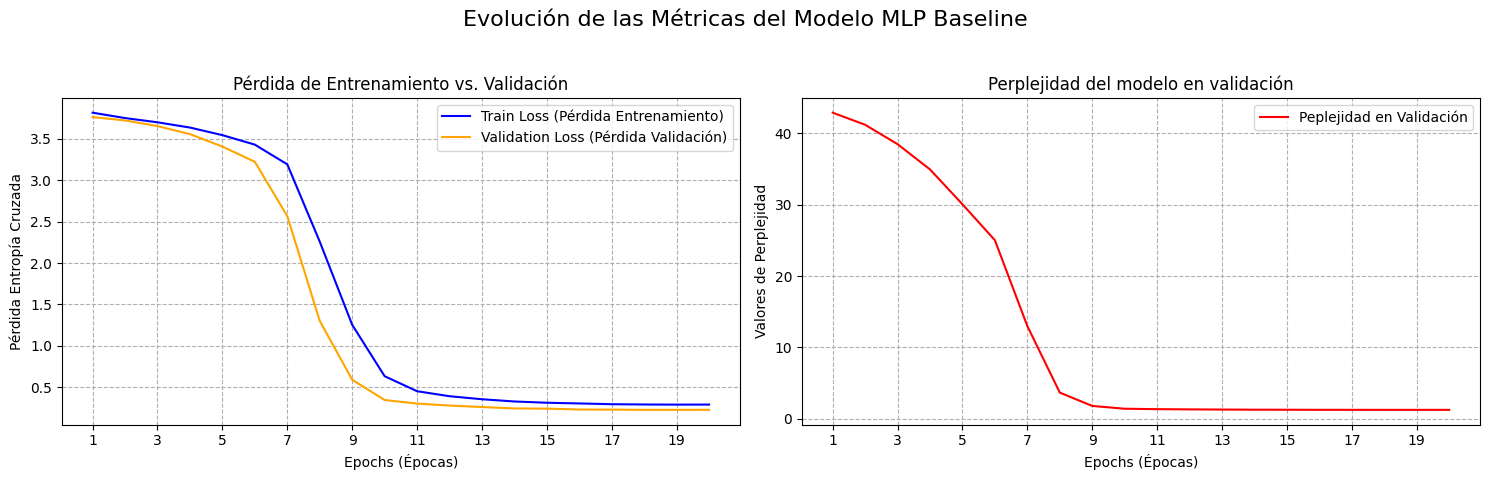

In [28]:
showTrainMetrics(history)


Guardamos el modelo para usarlo posteriormente en la tarea de clasificación, donde probamos a hacerle fine-tuning.

In [29]:
save_model(mlm_model_trained, nombre_archivo= "pesos_modelo_mlm_preentrenado.pth", ruta_carpeta="./modelos_guardados")
instancia_modelo_mlm_pretrained = TinyRNATransformer(vocab_size=len(itos), max_len=512, d_model=128, d_ff=256, n_heads=4, n_layers=4)
modelo_mlm_pretrained = load_model(instancia_modelo_mlm_pretrained, ruta_archivo="./modelos_guardados/pesos_modelo_mlm_preentrenado.pth")

Análisis del Entrenamiento.
Se entrenó durante 20 épocas (25 minutos), haciendo uso de una GPU Nvidia RTX 3060


El modelo pasó por tres fases claras:

Fase Inicial (Épocas 1-6): El modelo comienza con una perplejidad alta (42-25), lo que indica que inicialmente 'duda' entre una gran parte del vocabulario (que consta de 68 tokens). El descenso es gradual, típico de la fase de warm-up del scheduler.

Caída Crítica (Épocas 7-9): Se produce una reducción drástica de la pérdida (de 3.18 a 0.59) y la perplejidad (de 13.0 a 1.8). Este comportamiento sugiere que el optimizador encontró un mínimo y el modelo 'comprendió' repentinamente patrones estructurales fundamentales de las secuencias de ARN.

Estabilización (Épocas 10-20): El modelo entra en una fase de saturación, estabilizándose en una perplejidad final de 1.25. En esta fase final las mejoras no son muy significativas.


Interpretación de la Perplejidad Final
Una Perplejidad de 1.2577 es un resultado excelente para la tarea MLM. Significa que, ante un token enmascarado, el modelo ya no duda entre los 68 tokens posibles, sino que ha reducido su incertidumbre a casi una única opción correcta.

Un fenómeno destacable en las curvas es que la pérdida de validación (0.2297) es algo inferior a la pérdida de entrenamiento (0.2930). Lejos de ser un error, esto es un indicador de una excelente generalización y se explica por la arquitectura del modelo. El TinyRNATransformer incluye capas de Dropout(p=0.1). Durante el entrenamiento, el 10% de las neuronas se apagan aleatoriamente, dificultando la tarea. Pero durante la validación, el Dropout se desactiva y el modelo utiliza toda su capacidad, logrando un rendimiento superior. El modelo no ha memorizado los datos de entrenamiento, sino que ha extraído patrones generalizables aplicables a datos no vistos.

Dado que el vocabulario es pequeño (68 tokens), una dimensión de embedding de 128 ha demostrado ser suficiente para capturar la variabilidad de los datos sin incurrir en un gran coste computacional, y sin propiciar sobreajuste.

